<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/k_brazos/Normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 Parte 1: Problema de los k-brazos: Normal
- **Alumno:** Pastor Beltrá, Miguel
- **Asignatura:** Extensiones de Machine Learning
- **Curso:** 2025/2026
- **Grupo:** pastorbeltra

**Índice**   
1. [Introducción](#introduccion)
2. [Desarrollo](#desarrollo)
3. [Algoritmos](#algoritmos)
4. [Evaluación](#evaluacion)
5. [Conclusiones](#conclusiones)
6. [Uso de la IA generativa](#ia-generativa)
7. [Bibliografía y referencias](#referencias)

# 1. Introducción <a name="introduccion"></a>

En esta práctica implementamos y comparamos los algoritmos $\epsilon$-greedy, $\epsilon$-decaimiento, UCB1 y Softmax en un entorno de recompensas continuas modeladas mediante distribuciones Normales (Gaussianas). En este caso, cada acción devuelve una recompensa real con cierta media y varianza, lo que representa escenarios más realistas con ruido continuo.

El objetivo es estudiar el comportamiento de los algoritmos bajo estas condiciones, analizando las gráficas de recompensa promedio, arrepentimiento acumulado y porcentaje de selección óptima, y observando cómo gestionan la incertidumbre en recompensas continuas.

# 2. Desarrollo <a name="desarrollo"></a>

Hemos realizado esta práctica en un entorno local utilizando Visual Studio Code. Sin embargo, como especificación del enunciado, el proyecto también está preparado para ejecutarse en Google Colab sin necesidad de configuración adicional. En esta sección tambien incluimos todos los imports necesarios para el correcto funcionamiento del notebook.

## 2.1. Entorno Colab y VSCode

A continuación, incluimos algunas celdas auxiliares para adaptar el entorno de ejecución en Colab, permitiendo acceder correctamente al repositorio y a los módulos del proyecto.

In [ ]:
!rm -r pastorbeltra/
!git clone https://github.com/MiguelPastorB/pastorbeltra.git
%cd pastorbeltra/

In [ ]:
!pip install -r requirements.txt

Esta celda de código añade la carpeta src al path de Python, lo que permite importar correctamente los módulos del proyecto sin necesidad de instalar el paquete.

In [ ]:
%cd k_brazos/

In [2]:
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

## 2.2. Importaciones y semilla

Importamos todas las dependencias necesarias para la ejecución de los experimentos, incluidos los distintos componentes implementados en el proyecto: los algoritmos de aprendizaje ($\epsilon$-greedy, UCB1 y Softmax), las clases que definen los brazos (*arms*) y el entorno *bandit*, así como las funciones de visualización utilizadas para analizar los resultados (recompensa promedio, arrepentimiento y porcentaje de selección óptima).

Finalmente, fijamos una semilla aleatoria (`seed = 2024`) tanto en NumPy como en la librería `random`. Esto garantiza la **reproducibilidad** de los experimentos, permitiendo obtener los mismos resultados en distintas ejecuciones.

In [3]:
# Importamos las librerías necesarias
import numpy as np
import random

# Importamos nuestros algoritmos, brazos y funciones de visualización
from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

# Establecemos una semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
random.seed(seed)

# 3. Algoritmos <a name="algoritmos"></a>

``run_experiment`` simula la interacción de los algoritmos con un bandido k-brazos Normal, donde cada brazo devuelve una recompensa continua con cierta media y varianza.

Para cada algoritmo y paso temporal:

* Seleccionamos un brazo.
* Recibimos la recompensa del entorno (valor real).
* Actualizamos las estimaciones del algoritmo.
* Registramos las métricas: recompensa promedio, % de selección óptima y arrepentimiento acumulado.

Los resultados se promedian sobre todas las ejecuciones para obtener curvas más estables y comparables entre algoritmos.

In [4]:
def run_experiment(algorithms, n_arms, n_steps, n_runs, sigma):
    """
    Ejecuta el experimento para brazos con Distribución Normal N(mu, sigma^2).
    """
    # Matrices para almacenar resultados
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las medias (mu) de cada brazo
    means = np.linspace(10, 50, n_arms) 
    optimal_arm_idx = np.argmax(means)
    max_mu = means[optimal_arm_idx]

    for run in range(n_runs):
        # Instanciamos los brazos con distribución Normal, cada brazo tiene su propia media (mu) pero comparten la misma desviacion (sigma)
        arms = [ArmNormal(mu=m, sigma=sigma) for m in means]
        bandit = Bandit(arms)
        
        # Reiniciamos los algoritmos para asegurar independencia entre ejecuciones
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # Selección del brazo
                arm_idx = alg.select_arm()
                
                # Obtención de recompensa continua
                reward = bandit.pull_arm(arm_idx)
                
                # Actualización de las estimaciones del agente
                alg.update(arm_idx, reward)
                
                # Registro de métricas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # El regret se basa en la diferencia de las medias teoricas
                current_regret = max_mu - means[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados para obtener curvas suaves 
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) 

    return avg_rewards, avg_optimal, avg_regret

# 4. Evaluación

En esta sección ejecutamos los experimentos para analizar y comparar el desempeño de los algoritmos en un entorno bandido k-brazos de distribución normal, donde cada brazo devuelve una recompensa continua $N(\mu, \sigma^2)$ con media $\mu$ y desviación estándar $\sigma$. Este entorno nos permite estudiar cómo los algoritmos gestionan recompensas con variabilidad continua y ruido.

Definimos los parámetros del experimento:

* **n_arms = 10:** número de brazos disponibles.
* **n_steps = 1000:** pasos de interacción por ejecución.
* **n_runs = 2000:** un número alto de ejecuciones para garantizar rigor metodológico.
* **sigma_val_low = 1.0 y sigma_val_high = 20.0:** desviaciones estándar de las recompensas, representando entornos con baja y alta variabilidad, respectivamente.

Instanciamos los algoritmos a comparar:

* **Epsilon-Greedy:** con $\epsilon$ = 0.1
* **Decaying Epsilon-Greedy:** reduce $\epsilon$ a lo largo del tiempo.
* **UCB1:** equilibra exploración y explotación según la incertidumbre.
* **Softmax:** con temperatura ajustada a 5.0 para adaptarse a la mayor escala de las recompensas continuas.

In [ ]:
# Parámetros del experimento
n_arms = 10
n_steps = 1000
n_runs = 2000
sigma_val_low = 1.0 # Variación baja para recompensas más predecibles
sigma_val_high = 20.0 # Variación alta para recompensas más ruidosas

# Lista de algoritmos a comparar
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms),
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=5.0) # Subimos la temperatura por la escala de recompensas
]

# Ejecutamos
avg_rewards_low, opt_selections_low, regret_data_low = run_experiment(all_algorithms, n_arms, n_steps, n_runs, sigma=sigma_val_low)
avg_rewards_high, opt_selections_high, regret_data_high = run_experiment(all_algorithms, n_arms, n_steps, n_runs, sigma=sigma_val_high)

## 4.1. Evaluación sigma $\sigma = 1.0$

Observamos que UCB1 es el único algoritmo que alcanza y mantiene una precisión del 100% de forma casi instantánea. Esto se debe a que, con un ruido tan bajo, las estimaciones de la media son muy precisas desde el inicio. $\epsilon$-greedy se estabiliza en un 90%, mientras que el $\epsilon$-decaimiento logra cruzar la línea del valor fijo alrededor del paso 800, terminando con un 92% de éxito. En contraste, Softmax muestra una convergencia muy pobre, estancándose en un 40%, lo que sugiere que en este rango de recompensas ($10-50$), la diferencia entre brazos no es lo suficientemente "visible" para su distribución de probabilidad con $temp=5.0$.

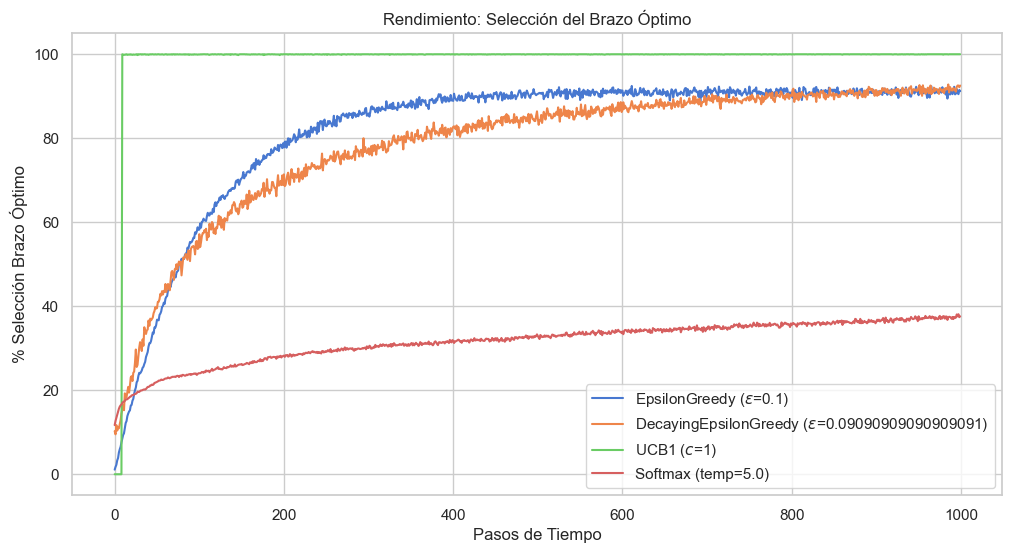

In [6]:
# Gráfica 1: % de Selección del Brazo Óptimo con variación baja (sigma=1.0)
plot_optimal_selections(n_steps, opt_selections_low, all_algorithms)

El análisis del arrepentimiento confirma que UCB1 es el algoritmo más eficiente teóricamente, con una curva que se aplana totalmente tras el descubrimiento inicial (arrepentimiento cercano a 200). En el extremo opuesto, Softmax acumula la mayor pérdida, con una pendiente lineal muy pronunciada que supera los 6000 puntos. Observamos que la curva del $\epsilon$-decaimiento, aunque inicialmente acumula más arrepentimiento que el método $\epsilon$-greedy (debido a su fase aleatoria), su pendiente se va reduciendo, demostrando que es una estrategia más rentable a largo plazo que mantener un $\epsilon$ constante.

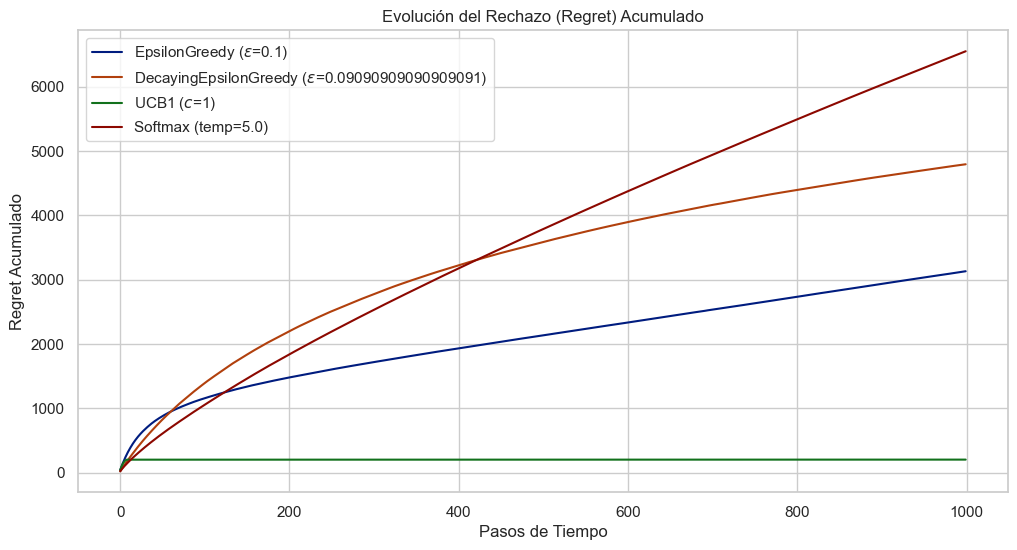

In [ ]:
# Gráfica 2: Regret Acumulado con variación baja (sigma=1.0)
plot_regret(n_steps, regret_data_low, all_algorithms)

En esta gráfica, hemos observado la superioridad inmediata de UCB1, que logra alcanzar la recompensa máxima de $50$ en apenas 10 pasos. Tanto $\epsilon$-greedy como $\epsilon$-decaimiento muestran una progresión ascendente muy similar, aunque el algoritmo de decaimiento empieza por debajo debido a su alta exploración inicial. Por su parte, Softmax ($temp=5.0$) presenta un rendimiento inferior, estabilizándose en una recompensa promedio de $45$, lo que nos indica que elige brazos poco óptimos con demasiada frecuencia a pesar del ajuste de temperatura.

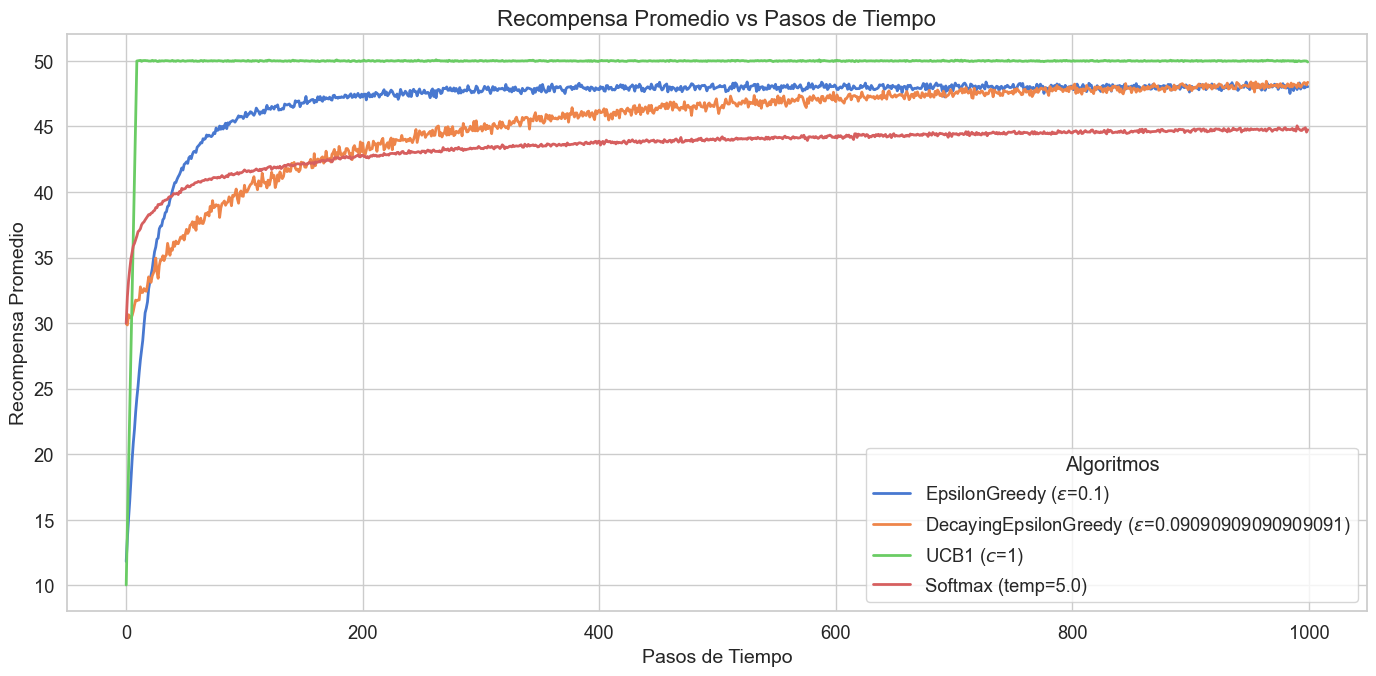

In [8]:

# Gráfica 3: Recompensa Promedio con variación baja (sigma=1.0)
plot_average_rewards(n_steps, avg_rewards_low, all_algorithms)

## 4.2. Evaluación sigma $\sigma = 20.0$

UCB1 ya no es el algoritmo dominante de hecho, sufre un estancamiento en torno al 60%. Al haber tanto ruido, sus intervalos de confianza se mantienen anchos, obligándolo a sobre-explorar constantemente. El gran ganador aquí es el $\epsilon$-decaimiento, que tras un inicio lento, logra superar a todos los competidores y termina con una precisión del 85%. Esto nos demuestra que, en entornos muy ruidosos, una exploración aleatoria que decae en el tiempo es más robusta que la exploración optimista de UCB1. Por su parte, el $\epsilon$-greedy mantiene un comportamiento sólido, estabilizándose cerca del 78%, pues al no verse influenciado por la varianza de los datos para decidir su tasa de exploración, logra superar a UCB1 a largo plazo. Finalmente, Softmax se comporta de manera muy irregular y apenas llega al 40%, lo que indica que el ruido del entorno hace que las diferencias entre las recompensas sean poco claras, y por eso el algoritmo no consigue elegir bien la mejor opción.

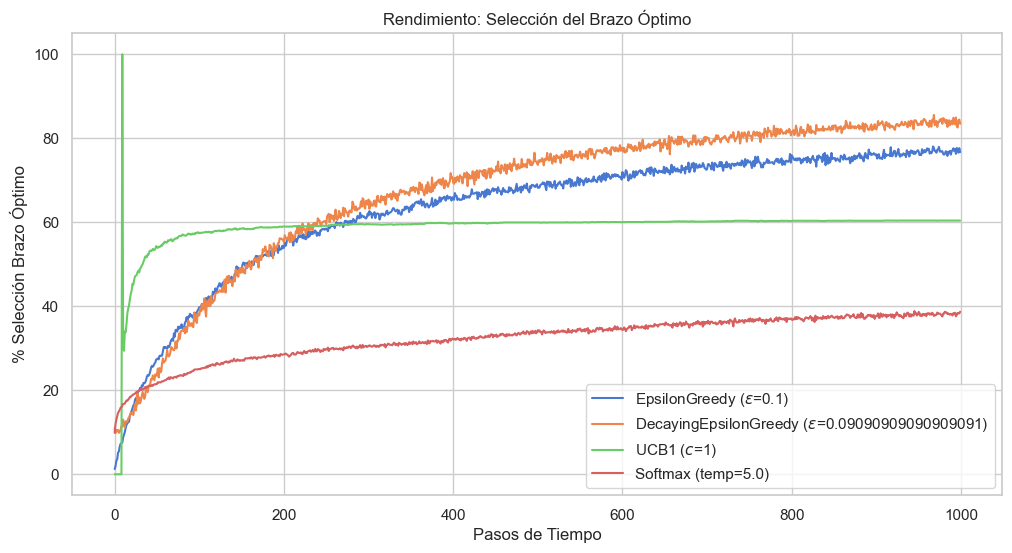

In [9]:
# Gráfica 4: % de Selección del Brazo Óptimo con variación alta (sigma=20.0)
plot_optimal_selections(n_steps, opt_selections_high, all_algorithms)

El análisis del arrepentimiento nos indica que UCB1, antes casi plano, ahora muestra una pendiente ascendente constante (arrepentimiento > 2500). Sin embargo, la curva del $\epsilon$-decaimiento muestra una curva inicial muy pronunciada seguida de una estabilización notable. Por el contrario, Softmax tiene un comportamiento crítico, su arrepentimiento crece de forma casi exponencial al inicio y termina superando los 6000 puntos, lo que nos permite concluir que es el algoritmo más vulnerable ante el ruido extremo si no se ajusta su temperatura dinámicamente. Por su parte, en el $\epsilon$-greedy hemos identificado una pendiente lineal constante, su exploración fija del 10% hace que acumule un arrepentimiento cosntante que supera los 4000 puntos. 

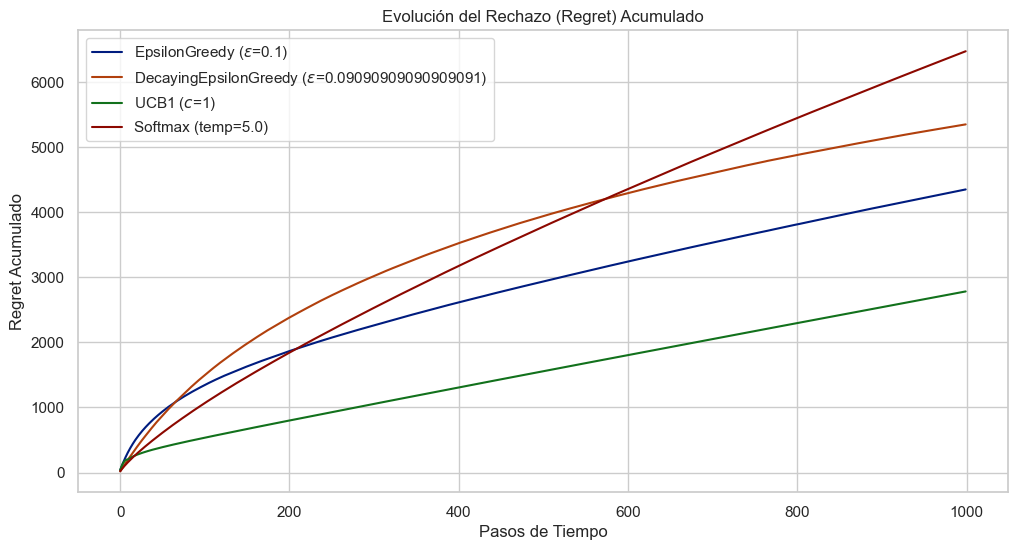

In [10]:
# Gráfica 5: Regret Acumulado con variación alta (sigma=20.0)
plot_regret(n_steps, regret_data_high, all_algorithms)

En esta gráfica, hemos observado una inestabilidad marcada en todas las curvas. Aunque UCB1 ($c=1$) sigue alcanzando rápidamente valores cercanos a 47-48, ya no logra estabilizarse en el máximo teórico de 50 de forma limpia. Es muy significativo notar cómo el $\epsilon$-greedy y el $\epsilon$-decaimiento muestran una progresión lenta y ruidosa. Softmax, en cambio, sigue atrás, lo que muestra que el ruido del entorno hace que las diferencias en las recompensas sean menos claras para el algoritmo.

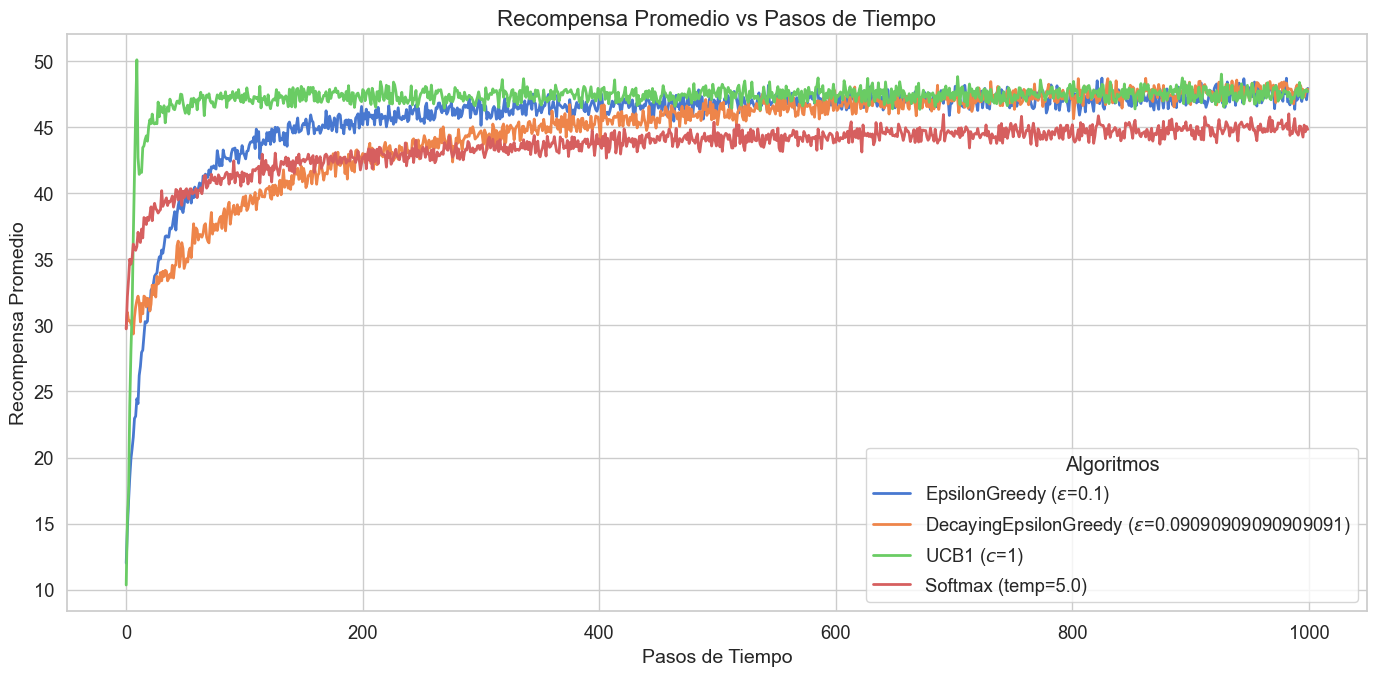

In [11]:
# Gráfica 6: Recompensa Promedio con variación alta (sigma=20.0)
plot_average_rewards(n_steps, avg_rewards_high, all_algorithms)

# 5. Conclusiones <a name="conclusiones"></a>

# 5.1. Conclusiones $\sigma = 1.0$

Tras analizar los resultados, concluimos lo siguiente:

* **$\epsilon$-greedy:** hemos comprobado que la versión con $\epsilon=0.1$ es muy robusta, pero el 10% de exploración residual es un lastre innecesario cuando el entorno es tan predecible.

* **$\epsilon$-decaimiento:** al reducir la exploración conforme aumenta la certeza, logra superar al método $\epsilon$-greedy, minimizando el error al final del experimento.

* **UCB1:** hemos comprobado que UCB1 es imbatible en entornos normales con bajo ruido. Al no depender de un factor de azar puro (como $\epsilon$), sino de la incertidumbre estadística, el algoritmo bloquea el brazo óptimo en cuanto los intervalos de confianza se estrechan. En nuestra opinión, es la elección obligatoria para entornos continuos estables, ya que elimina el arrepentimiento lineal casi por completo.

* **Softmax:** concluimos que Softmax es el algoritmo más difícil de configurar en la distribución normal. A pesar de haber subido la temperatura a $5.0$ para compensar la escala de las recompensas, no logra discriminar correctamente el brazo de $50$ frente a los de $45$ o $40$. Por lo tanto, para este rango de valores, Softmax requeriría una temperatura mucho más baja o un proceso de normalización previo de las recompensas para rendir mejor.

# 5.2. Conclusiones $\sigma = 20.0$

Tras analizar los resultados, concluimos lo siguiente:

* **$\epsilon$-greedy:** hemos verificado que su sencillez se traduce en una notable robustez frente emplenado una distribución normal. Al mantener una tasa de exploración fija ($\epsilon = 0.1$) que es totalmente independiente de la varianza de los datos, evita los errores de interpretación que sufren algoritmos más "sensibles" como UCB1 o Softmax. Sin embargo, hemos observado que esta rigidez es también su limitación principal, ya que le impide eliminar el arrepentimiento lineal al seguir explorando de forma ciega incluso cuando el brazo óptimo ya ha sido identificado.

* **$\epsilon$-decaimiento:** hemos comprobado que el $\epsilon$-decaimiento es la estrategia más equilibrada para entornos ruidosos. Al obligar al agente a explorar intensamente al principio y reducir esa aleatoriedad, logra identificar el mejor brazo y quedarse en él con mayor éxito.

* **UCB1:** UCB1 es altamente sensible a la varianza. Cuando el ruido es comparable a la diferencia entre las medias de los brazos, el algoritmo se confunde y no logra converger al óptimo, manteniendo un nivel de exploración innecesario que penaliza el rendimiento final.

* **Softmax:** concluimos que Softmax, con una temperatura fija de $5.0$, es incapaz de gestionar la incertidumbre de este escenario. El ruido no deja emplear correctamente la media, provocando que la distribución de Boltzmann asigne probabilidades similares a muchos brazos, lo que se traduce en un arrepentimiento muy grande.

# 6. Uso de la IA generativa <a name="ia-generativa"></a>

### Prompt 1. ¿Qué valores de varianza debería probar en un problema de k-brazos siguiendo una distribución normal? ¿Por qué?

Para tu problema de k-brazos, te recomendaría probar varianzas como 1 y 20, ya que 1 representa un nivel bajo de ruido que permite ver claramente cuál brazo es mejor, mientras que 20 introduce bastante variabilidad, útil para evaluar cómo tu estrategia maneja recompensas más ruidosas y difíciles de diferenciar. Esto te da un buen rango para experimentar entre entornos más estables y más desafiantes.

# 7. Bibliografía y referencias <a name="referencias"></a>

* Profesor/a [Hernández Molinero], [LD]. (2026). Material de aula virtual y clases de Extensiones de Machine Learning. Universidad de Murcia.